# Photonic Quantum Error Correction: BB84 QKD Performance Analysis
## Cat (Bosonic) Qubits vs. Standard (Noisy) Qubits

**Course:** Quantum Simulation & Computing Lab  
**Topic:** Simulating Alice & Bob (Cat/Bosonic) qubit noise bias using Qiskit noise models

---

### Background

**Cat qubits** (as implemented by Alice & Bob) encode logical qubits in superpositions of coherent states `|α⟩` and `|-α⟩`. Their key property is an **exponentially biased noise channel**:

- **Bit-flip (X) errors**: Suppressed exponentially as `~exp(-2|α|²)` — vanishingly rare
- **Phase-flip (Z) errors**: Grow linearly with `|α|²` — the dominant error

We define the **bias ratio** κ (kappa) as:

```
κ = p_phase / p_bitflip
```

For standard qubits: κ ≈ 1 (symmetric depolarizing noise)  
For cat qubits: κ >> 1 (e.g., 100–10,000)

In BB84 QKD, bit-flip errors directly inflate the **Quantum Bit Error Rate (QBER)** in the rectilinear basis, while phase-flip errors affect the diagonal basis. Cat qubits should dramatically reduce QBER and extend the secure key generation regime.

---

In [1]:
# ============================================================
# Cell 1: Imports & Configuration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    pauli_error,
    amplitude_damping_error,
    phase_damping_error,
)
from qiskit.compiler import transpile

# ── Matplotlib style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#0d1117',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.family':       'monospace',
    'axes.titleweight':  'bold',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'figure.dpi':        120,
})

ACCENT_BLUE   = '#58a6ff'   # standard qubit
ACCENT_TEAL   = '#39d353'   # cat qubit
ACCENT_ORANGE = '#f78166'   # security threshold
ACCENT_YELLOW = '#e3b341'

print("✓ Imports complete")

✓ Imports complete


---
## Part 1 — Noise Model Construction

We build two Qiskit `NoiseModel` objects:

| Model | Description | Noise channel |
|---|---|---|
| **Standard** | Symmetric depolarizing | Equal X, Y, Z rates |
| **Cat qubit** | Biased Pauli channel | Z >> X, Y (controlled by κ) |

In [3]:
# ============================================================
# Cell 2: Noise Model Builders
# ============================================================

def build_standard_noise_model(p_total: float) -> NoiseModel:
    """
    Standard qubit: symmetric depolarizing noise.
    Equal probability p_total/3 for X, Y, Z errors on each gate and measurement.
    """
    nm = NoiseModel()
    # Single-qubit gate depolarizing
    gate_err = depolarizing_error(p_total, 1)
    nm.add_all_qubit_quantum_error(gate_err, ['h', 'x', 'z', 's', 'sdg'])
    # Measurement readout error (classical)
    p_meas = p_total / 2
    nm.add_all_qubit_readout_error([[1 - p_meas, p_meas], [p_meas, 1 - p_meas]])
    return nm


def build_cat_noise_model(p_total: float, kappa: float) -> NoiseModel:
    """
    Cat qubit proxy: biased Pauli channel. # HUGE IMPORTANT THINGY
    κ = p_Z / p_X  (phase-flip bias over bit-flip)
    
    Given total error rate p_total and bias κ:
        p_X = p_Y = p_total / (2*(κ + 1))      (suppressed)
        p_Z = p_total * κ / (κ + 1)             (dominant)
        p_I = 1 - p_X - p_Y - p_Z              (identity)
    
    At κ=1 this reduces to depolarizing. At κ>>1, X errors vanish.
    """
    p_x = p_total / (2 * (kappa + 1))
    p_y = p_x
    p_z = p_total * kappa / (kappa + 1)
    p_i = max(0.0, 1.0 - p_x - p_y - p_z)

    # Clamp to valid probabilities
    total = p_i + p_x + p_y + p_z
    p_i, p_x, p_y, p_z = p_i/total, p_x/total, p_y/total, p_z/total

    gate_err = pauli_error([('I', p_i), ('X', p_x), ('Y', p_y), ('Z', p_z)])
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(gate_err, ['h', 'x', 'z', 's', 'sdg'])

    # Cat qubits still have readout noise, but primarily Z-type (phase)
    # Measurement bit-flip is also suppressed by factor κ
    p_meas_bitflip = (p_total / 2) / (kappa + 1)
    p_meas_bitflip = min(p_meas_bitflip, 0.499)
    nm.add_all_qubit_readout_error(
        [[1 - p_meas_bitflip, p_meas_bitflip],
         [p_meas_bitflip, 1 - p_meas_bitflip]]
    )
    return nm


def noise_model_summary(p_total: float, kappa: float):
    """Print a side-by-side summary of error rates for both models."""
    p_x_std = p_total / 3
    p_z_std = p_total / 3
    p_x_cat = p_total / (2 * (kappa + 1))
    p_z_cat = p_total * kappa / (kappa + 1)
    print(f"{'':=<58}")
    print(f"  Noise Model Summary  |  p_total={p_total:.4f}  κ={kappa}")
    print(f"{'':=<58}")
    print(f"  {'Error type':<18} {'Standard':>12} {'Cat (proxy)':>14}")
    print(f"  {'-'*46}")
    print(f"  {'p_X (bit-flip)':<18} {p_x_std:>12.6f} {p_x_cat:>14.6f}")
    print(f"  {'p_Z (phase-flip)':<18} {p_z_std:>12.6f} {p_z_cat:>14.6f}")
    print(f"  {'Bias ratio κ_eff':<18} {'1.0':>12} {p_z_cat/max(p_x_cat,1e-12):>14.1f}")
    print(f"{'':=<58}")

# Quick sanity check
noise_model_summary(p_total=0.05, kappa=100)
print("\n✓ Noise models built")

  Noise Model Summary  |  p_total=0.0500  κ=100
  Error type             Standard    Cat (proxy)
  ----------------------------------------------
  p_X (bit-flip)         0.016667       0.000248
  p_Z (phase-flip)       0.016667       0.049505
  Bias ratio κ_eff            1.0          200.0

✓ Noise models built


---
## Part 2 — BB84 QKD Protocol Implementation

The **BB84 protocol** works as follows:

1. **Alice** prepares qubits in one of 4 states: `|0⟩, |1⟩` (Z-basis) or `|+⟩, |−⟩` (X-basis), chosen at random
2. **Bob** measures in a randomly chosen basis (Z or X)
3. **Sifting**: Alice and Bob keep only bits where they chose the *same* basis (~50%)
4. **QBER estimation**: A sample of sifted bits are compared publicly to estimate the error rate
5. **Security threshold**: If QBER < 11%, secure key distillation is possible

We implement each qubit transmission as a single-qubit Qiskit circuit with the chosen noise model injected.

In [4]:
# ============================================================
# Cell 3: BB84 Circuit Builder & Simulator
# ============================================================

def build_bb84_circuit(alice_bit: int, alice_basis: int, bob_basis: int) -> QuantumCircuit:
    """
    Build a single BB84 qubit transmission circuit.

    alice_bit   : 0 or 1
    alice_basis : 0 = Z-basis (rectilinear), 1 = X-basis (diagonal)
    bob_basis   : 0 = Z-basis,               1 = X-basis

    Encoding:
        Z-basis: |0⟩ → bit 0, |1⟩ → bit 1
        X-basis: |+⟩ → bit 0, |−⟩ → bit 1
    """
    qc = QuantumCircuit(1, 1)

    # Alice prepares her qubit
    if alice_bit == 1:
        qc.x(0)                    # flip to |1⟩
    if alice_basis == 1:
        qc.h(0)                    # rotate to X-basis (|+⟩ or |−⟩)

    # Channel noise is injected by Aer automatically via NoiseModel

    # Bob measures in his chosen basis
    if bob_basis == 1:
        qc.h(0)                    # rotate back from X-basis
    qc.measure(0, 0)

    return qc


def run_bb84_simulation(
    noise_model: NoiseModel,
    n_qubits: int = 2000,
    shots_per_qubit: int = 1,
    seed: int = 42
) -> dict:
    """
    Simulate a full BB84 protocol run with a given noise model.

    Returns a dict with:
        - qber           : Quantum Bit Error Rate on sifted key
        - sift_rate      : Fraction of bits surviving sifting
        - n_sifted       : Number of sifted bits
        - secure_key_len : Estimated secure key bits (Devetak-Winter bound)
        - alice_bits, alice_bases, bob_bases, bob_results
    """
    rng = np.random.default_rng(seed)
    backend = AerSimulator(noise_model=noise_model)

    alice_bits   = rng.integers(0, 2, n_qubits)
    alice_bases  = rng.integers(0, 2, n_qubits)
    bob_bases    = rng.integers(0, 2, n_qubits)
    bob_results  = np.zeros(n_qubits, dtype=int)

    # Batch build circuits
    circuits = [
        build_bb84_circuit(int(alice_bits[i]), int(alice_bases[i]), int(bob_bases[i]))
        for i in range(n_qubits)
    ]
    tcirc = transpile(circuits, backend, optimization_level=0)
    job = backend.run(tcirc, shots=1)
    results = job.result()

    for i, circ in enumerate(circuits):
        counts = results.get_counts(i)
        bob_results[i] = int(max(counts, key=counts.get))

    # Sifting: keep only matching bases
    sifted_mask  = alice_bases == bob_bases
    sifted_alice = alice_bits[sifted_mask]
    sifted_bob   = bob_results[sifted_mask]

    n_sifted   = len(sifted_alice)
    errors     = np.sum(sifted_alice != sifted_bob)
    qber       = errors / n_sifted if n_sifted > 0 else 1.0
    sift_rate  = n_sifted / n_qubits

    # Devetak-Winter secure key rate (binary entropy)
    def h2(p):
        if p <= 0 or p >= 1:
            return 0.0
        return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

    # One-way secret key rate: r = 1 - 2*h(e) for BB84
    raw_key_rate = max(0.0, 1.0 - 2 * h2(qber))
    secure_key_len = int(n_sifted * raw_key_rate)

    return {
        'qber':           qber,
        'sift_rate':      sift_rate,
        'n_sifted':       n_sifted,
        'secure_key_len': secure_key_len,
        'key_rate':       raw_key_rate,
        'alice_bits':     alice_bits,
        'alice_bases':    alice_bases,
        'bob_bases':      bob_bases,
        'bob_results':    bob_results,
        'sifted_mask':    sifted_mask,
    }

print("✓ BB84 circuit and simulation functions defined")

✓ BB84 circuit and simulation functions defined


---
## Part 3 — Single Run: Standard vs Cat Qubit

First, a single comparison run at a fixed noise level and κ to see raw outputs.

In [5]:
# ============================================================
# Cell 4: Single Run Comparison
# ============================================================

P_TOTAL  = 0.05    # Total noise rate (5%) — tune this
KAPPA    = 100     # Bias ratio for cat qubit proxy — tune this
N_QUBITS = 2000    # Number of transmitted qubits

print(f"Running BB84 with p_total={P_TOTAL}, κ={KAPPA}, N={N_QUBITS} qubits...\n")

nm_std = build_standard_noise_model(P_TOTAL)
nm_cat = build_cat_noise_model(P_TOTAL, KAPPA)

print("[1/2] Simulating standard qubits...")
res_std = run_bb84_simulation(nm_std, n_qubits=N_QUBITS, seed=42)

print("[2/2] Simulating cat qubits (κ={})...".format(KAPPA))
res_cat = run_bb84_simulation(nm_cat, n_qubits=N_QUBITS, seed=42)

# Pretty-print results
BB84_THRESHOLD = 0.11  # 11% QBER security threshold

def print_results(label, res):
    secure = '✓ SECURE' if res['qber'] < BB84_THRESHOLD else '✗ INSECURE'
    print(f"  {'─'*42}")
    print(f"  {label}")
    print(f"  {'─'*42}")
    print(f"  QBER              : {res['qber']:.4f}  ({res['qber']*100:.2f}%)  {secure}")
    print(f"  Sifted bits       : {res['n_sifted']} / {N_QUBITS}  (sift rate {res['sift_rate']:.2%})")
    print(f"  Key rate (DW)     : {res['key_rate']:.4f} bits/sifted bit")
    print(f"  Secure key length : {res['secure_key_len']} bits")

print()
print_results('Standard Qubit (depolarizing)', res_std)
print()
print_results(f'Cat Qubit proxy (κ={KAPPA})', res_cat)
print(f"  {'─'*42}")
print(f"\n  QBER reduction factor : {res_std['qber'] / max(res_cat['qber'], 1e-9):.1f}×")
print(f"  Key length gain       : {res_cat['secure_key_len'] - res_std['secure_key_len']:+d} bits")

Running BB84 with p_total=0.05, κ=100, N=2000 qubits...

[1/2] Simulating standard qubits...
[2/2] Simulating cat qubits (κ=100)...

  ──────────────────────────────────────────
  Standard Qubit (depolarizing)
  ──────────────────────────────────────────
  QBER              : 0.0569  (5.69%)  ✓ SECURE
  Sifted bits       : 966 / 2000  (sift rate 48.30%)
  Key rate (DW)     : 0.3697 bits/sifted bit
  Secure key length : 357 bits

  ──────────────────────────────────────────
  Cat Qubit proxy (κ=100)
  ──────────────────────────────────────────
  QBER              : 0.0217  (2.17%)  ✓ SECURE
  Sifted bits       : 966 / 2000  (sift rate 48.30%)
  Key rate (DW)     : 0.6978 bits/sifted bit
  Secure key length : 674 bits
  ──────────────────────────────────────────

  QBER reduction factor : 2.6×
  Key length gain       : +317 bits


---
## Part 4 — κ Sweep: The Advantage Curve

Here we sweep κ from 1 (symmetric, no advantage) to 10,000 (extreme cat qubit) and measure QBER and secure key length as a function of bias. This is the core result showing **when** cat qubits provide a genuine advantage.

In [6]:
# ============================================================
# Cell 5: κ Sweep Simulation
# ============================================================

# KAPPA ANSWERS THE QUESTION: how much more likely is a phase-flip than a bit-flip?
# κ = p_Z / p_X
# ── Parameters ───────────────────────────────────────────────
P_TOTAL_SWEEP = 0.06       # Fixed noise rate for the κ-sweep
N_QUBITS_SWEEP = 1500      # Qubits per run (balance: speed vs. stats)
N_TRIALS = 3               # Trials per κ value (averaged)

# κ values: logarithmically spaced from 1 to 10000
KAPPA_VALUES = np.unique(np.round(
    np.concatenate([
        np.logspace(0, 1, 6),       # 1 – 10
        np.logspace(1, 2, 8),       # 10 – 100
        np.logspace(2, 3, 8),       # 100 – 1000
        np.logspace(3, 4, 5),       # 1000 – 10000
    ])
).astype(int))

print(f"κ values to sweep ({len(KAPPA_VALUES)} points): {KAPPA_VALUES}")
print(f"Total circuits: {len(KAPPA_VALUES) * N_TRIALS * N_QUBITS_SWEEP:,}\n")

# ── Standard qubit baseline (κ = 1 by definition) ────────────
qber_std_list, key_std_list = [], []
for trial in range(N_TRIALS):
    nm = build_standard_noise_model(P_TOTAL_SWEEP)
    r = run_bb84_simulation(nm, n_qubits=N_QUBITS_SWEEP, seed=trial)
    qber_std_list.append(r['qber'])
    key_std_list.append(r['secure_key_len'])

qber_std_mean = np.mean(qber_std_list)
qber_std_std  = np.std(qber_std_list)
key_std_mean  = np.mean(key_std_list)

print(f"Standard qubit baseline: QBER = {qber_std_mean:.4f} ± {qber_std_std:.4f}")

# ── Cat qubit κ sweep ─────────────────────────────────────────
sweep_results = []   # list of dicts

for idx, kappa in enumerate(KAPPA_VALUES):
    qber_trials, key_trials = [], []
    for trial in range(N_TRIALS):
        nm = build_cat_noise_model(P_TOTAL_SWEEP, float(kappa))
        r  = run_bb84_simulation(nm, n_qubits=N_QUBITS_SWEEP, seed=trial+100)
        qber_trials.append(r['qber'])
        key_trials.append(r['secure_key_len'])

    qber_mean = np.mean(qber_trials)
    qber_err  = np.std(qber_trials)
    key_mean  = np.mean(key_trials)

    sweep_results.append({
        'kappa':     kappa,
        'qber_mean': qber_mean,
        'qber_err':  qber_err,
        'key_mean':  key_mean,
    })

    print(f"  κ = {kappa:>6}  |  QBER = {qber_mean:.4f} ± {qber_err:.4f}  |  key ≈ {int(key_mean)} bits")

print("\n✓ κ sweep complete")

κ values to sweep (24 points): [    1     2     3     4     6    10    14    19    27    37    52    72
   100   139   193   268   373   518   720  1000  1778  3162  5623 10000]
Total circuits: 108,000

Standard qubit baseline: QBER = 0.0813 ± 0.0019
  κ =      1  |  QBER = 0.0630 ± 0.0036  |  key ≈ 239 bits
  κ =      2  |  QBER = 0.0508 ± 0.0021  |  key ≈ 311 bits
  κ =      3  |  QBER = 0.0452 ± 0.0099  |  key ≈ 348 bits
  κ =      4  |  QBER = 0.0432 ± 0.0054  |  key ≈ 361 bits
  κ =      6  |  QBER = 0.0427 ± 0.0037  |  key ≈ 364 bits
  κ =     10  |  QBER = 0.0370 ± 0.0065  |  key ≈ 404 bits
  κ =     14  |  QBER = 0.0364 ± 0.0085  |  key ≈ 409 bits
  κ =     19  |  QBER = 0.0324 ± 0.0053  |  key ≈ 436 bits
  κ =     27  |  QBER = 0.0257 ± 0.0018  |  key ≈ 486 bits
  κ =     37  |  QBER = 0.0315 ± 0.0016  |  key ≈ 442 bits
  κ =     52  |  QBER = 0.0309 ± 0.0025  |  key ≈ 445 bits
  κ =     72  |  QBER = 0.0339 ± 0.0068  |  key ≈ 427 bits
  κ =    100  |  QBER = 0.0257 ± 0.0046  

---
## Part 5 — Noise Level Sweep

For a fixed κ, we sweep the total noise rate `p_total` from near-ideal to heavily noisy. This shows how cat qubits extend the **secure operating range** compared to standard qubits.

In [7]:
# ============================================================
# Cell 6: Noise Level Sweep (fixed κ)
# ============================================================

KAPPA_FIXED   = 200       # Fixed κ for this sweep
P_VALUES      = np.linspace(0.01, 0.25, 18)   # 1% to 25% noise
N_QUBITS_P    = 1500
N_TRIALS_P    = 3

print(f"Sweeping p_total from {P_VALUES[0]:.2f} to {P_VALUES[-1]:.2f} | κ_cat={KAPPA_FIXED}\n")

p_sweep_std, p_sweep_cat = [], []

for p in P_VALUES:
    q_std, q_cat = [], []
    for trial in range(N_TRIALS_P):
        nm_s = build_standard_noise_model(p)
        nm_c = build_cat_noise_model(p, KAPPA_FIXED)
        r_s  = run_bb84_simulation(nm_s, N_QUBITS_P, seed=trial)
        r_c  = run_bb84_simulation(nm_c, N_QUBITS_P, seed=trial)
        q_std.append(r_s['qber'])
        q_cat.append(r_c['qber'])

    p_sweep_std.append({'p': p, 'qber': np.mean(q_std), 'err': np.std(q_std)})
    p_sweep_cat.append({'p': p, 'qber': np.mean(q_cat), 'err': np.std(q_cat)})
    print(f"  p={p:.3f}  | std QBER={np.mean(q_std):.4f}  cat QBER={np.mean(q_cat):.4f}")

print("\n✓ Noise level sweep complete")

Sweeping p_total from 0.01 to 0.25 | κ_cat=200

  p=0.010  | std QBER=0.0167  cat QBER=0.0031
  p=0.024  | std QBER=0.0253  cat QBER=0.0118
  p=0.038  | std QBER=0.0489  cat QBER=0.0213
  p=0.052  | std QBER=0.0566  cat QBER=0.0216
  p=0.066  | std QBER=0.0729  cat QBER=0.0308
  p=0.081  | std QBER=0.0906  cat QBER=0.0453
  p=0.095  | std QBER=0.1074  cat QBER=0.0466
  p=0.109  | std QBER=0.1112  cat QBER=0.0426
  p=0.123  | std QBER=0.1529  cat QBER=0.0601
  p=0.137  | std QBER=0.1500  cat QBER=0.0636
  p=0.151  | std QBER=0.1577  cat QBER=0.0746
  p=0.165  | std QBER=0.1582  cat QBER=0.0891
  p=0.179  | std QBER=0.1850  cat QBER=0.0871
  p=0.194  | std QBER=0.1930  cat QBER=0.1031
  p=0.208  | std QBER=0.2003  cat QBER=0.0994
  p=0.222  | std QBER=0.2051  cat QBER=0.1130
  p=0.236  | std QBER=0.2238  cat QBER=0.1094
  p=0.250  | std QBER=0.2472  cat QBER=0.1247

✓ Noise level sweep complete


---
## Part 6 — Visualization

Generate the full figure suite:
1. **κ advantage curve** — QBER and key rate vs. κ
2. **Noise level sweep** — QBER vs. p_total (standard vs. cat)
3. **Security operating region** — 2D heatmap of secure key rate over (p_total, κ)
4. **Single-run basis analysis** — breakdown of Z vs. X basis performance

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot1_kappa_sweep.png'

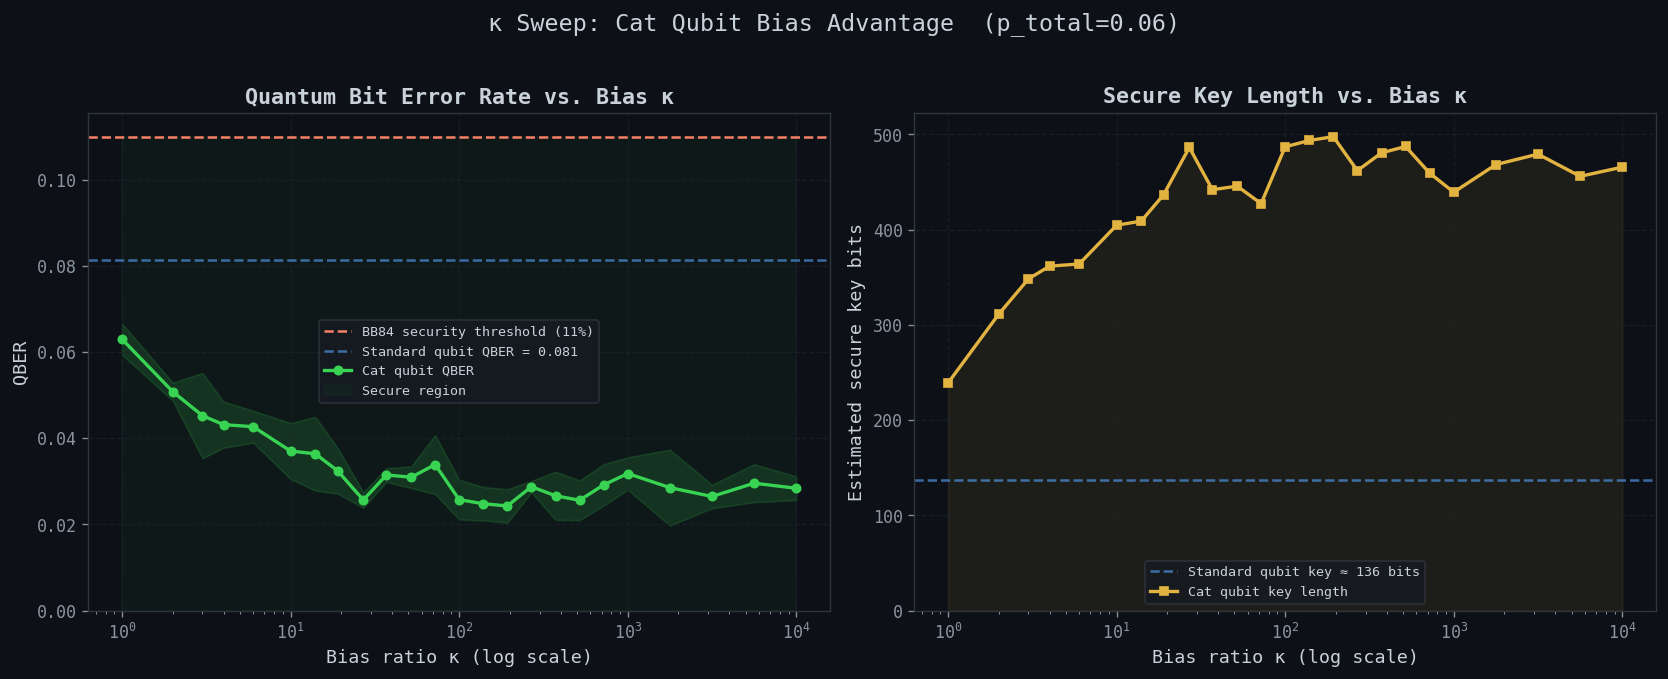

In [8]:
# ============================================================
# Cell 7: Plot 1 — κ Advantage Curve
# ============================================================

kappas     = [r['kappa']     for r in sweep_results]
qber_means = [r['qber_mean'] for r in sweep_results]
qber_errs  = [r['qber_err']  for r in sweep_results]
key_means  = [r['key_mean']  for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'κ Sweep: Cat Qubit Bias Advantage  (p_total={P_TOTAL_SWEEP})',
             fontsize=14, color='#c9d1d9', y=1.02)

# ── QBER vs κ ────────────────────────────────────────────────
ax1.set_xscale('log')
ax1.axhline(BB84_THRESHOLD, color=ACCENT_ORANGE, lw=1.5, ls='--', label='BB84 security threshold (11%)')
ax1.axhline(qber_std_mean, color=ACCENT_BLUE, lw=1.5, ls='--', alpha=0.6,
            label=f'Standard qubit QBER = {qber_std_mean:.3f}')
ax1.fill_between(kappas,
                 np.array(qber_means) - np.array(qber_errs),
                 np.array(qber_means) + np.array(qber_errs),
                 color=ACCENT_TEAL, alpha=0.15)
ax1.plot(kappas, qber_means, 'o-', color=ACCENT_TEAL, lw=2, ms=5, label='Cat qubit QBER')

# Shade secure region
ax1.fill_between([min(kappas), max(kappas)], 0, BB84_THRESHOLD,
                 color=ACCENT_TEAL, alpha=0.04, label='Secure region')

ax1.set_xlabel('Bias ratio κ (log scale)')
ax1.set_ylabel('QBER')
ax1.set_title('Quantum Bit Error Rate vs. Bias κ')
ax1.legend(fontsize=8)
ax1.grid(True)
ax1.set_ylim(bottom=0)

# ── Secure key length vs κ ───────────────────────────────────
ax2.set_xscale('log')
ax2.axhline(key_std_mean, color=ACCENT_BLUE, lw=1.5, ls='--', alpha=0.6,
            label=f'Standard qubit key ≈ {int(key_std_mean)} bits')
ax2.plot(kappas, key_means, 's-', color=ACCENT_YELLOW, lw=2, ms=5, label='Cat qubit key length')
ax2.fill_between(kappas, 0, key_means, color=ACCENT_YELLOW, alpha=0.08)

ax2.set_xlabel('Bias ratio κ (log scale)')
ax2.set_ylabel('Estimated secure key bits')
ax2.set_title('Secure Key Length vs. Bias κ')
ax2.legend(fontsize=8)
ax2.grid(True)
ax2.set_ylim(bottom=0)

fig.tight_layout()
plt.savefig('/mnt/user-data/outputs/plot1_kappa_sweep.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✓ Plot 1 saved")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot2_noise_sweep.png'

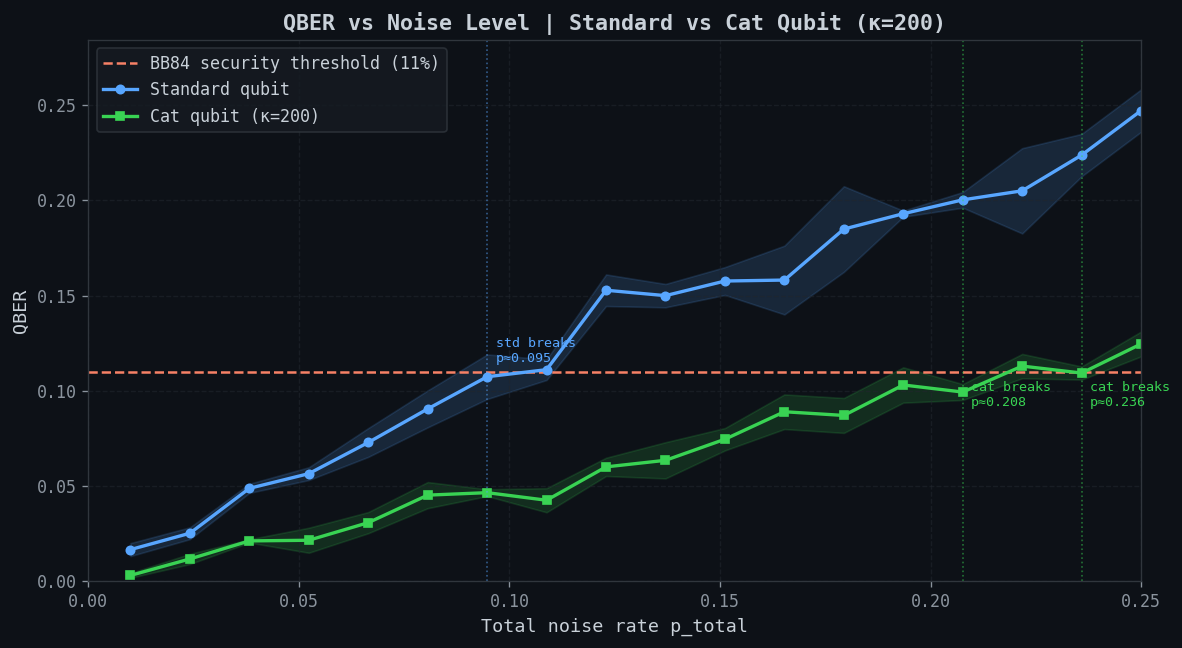

In [9]:
# ============================================================
# Cell 8: Plot 2 — Noise Level Sweep
# ============================================================

p_vals     = [r['p']    for r in p_sweep_std]
qber_std_p = [r['qber'] for r in p_sweep_std]
qber_std_e = [r['err']  for r in p_sweep_std]
qber_cat_p = [r['qber'] for r in p_sweep_cat]
qber_cat_e = [r['err']  for r in p_sweep_cat]

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.axhline(BB84_THRESHOLD, color=ACCENT_ORANGE, lw=1.5, ls='--', label='BB84 security threshold (11%)')

ax.fill_between(p_vals,
    np.array(qber_std_p) - np.array(qber_std_e),
    np.array(qber_std_p) + np.array(qber_std_e),
    color=ACCENT_BLUE, alpha=0.15)
ax.plot(p_vals, qber_std_p, 'o-', color=ACCENT_BLUE, lw=2, ms=5, label='Standard qubit')

ax.fill_between(p_vals,
    np.array(qber_cat_p) - np.array(qber_cat_e),
    np.array(qber_cat_p) + np.array(qber_cat_e),
    color=ACCENT_TEAL, alpha=0.15)
ax.plot(p_vals, qber_cat_p, 's-', color=ACCENT_TEAL, lw=2, ms=5, label=f'Cat qubit (κ={KAPPA_FIXED})')

# Find crossover point
for i in range(len(p_vals)-1):
    if qber_std_p[i] < BB84_THRESHOLD and qber_std_p[i+1] >= BB84_THRESHOLD:
        ax.axvline(p_vals[i], color=ACCENT_BLUE, lw=1, ls=':', alpha=0.5)
        ax.text(p_vals[i]+0.002, BB84_THRESHOLD+0.005, f'std breaks\np≈{p_vals[i]:.3f}',
                color=ACCENT_BLUE, fontsize=8)
    if qber_cat_p[i] < BB84_THRESHOLD and qber_cat_p[i+1] >= BB84_THRESHOLD:
        ax.axvline(p_vals[i], color=ACCENT_TEAL, lw=1, ls=':', alpha=0.5)
        ax.text(p_vals[i]+0.002, BB84_THRESHOLD-0.018, f'cat breaks\np≈{p_vals[i]:.3f}',
                color=ACCENT_TEAL, fontsize=8)

ax.set_xlabel('Total noise rate p_total')
ax.set_ylabel('QBER')
ax.set_title(f'QBER vs Noise Level | Standard vs Cat Qubit (κ={KAPPA_FIXED})')
ax.legend()
ax.grid(True)
ax.set_xlim(0, max(p_vals))
ax.set_ylim(0, max(max(qber_std_p), max(qber_cat_p)) * 1.15)

fig.tight_layout()
plt.savefig('/mnt/user-data/outputs/plot2_noise_sweep.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✓ Plot 2 saved")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot3_heatmap.png'

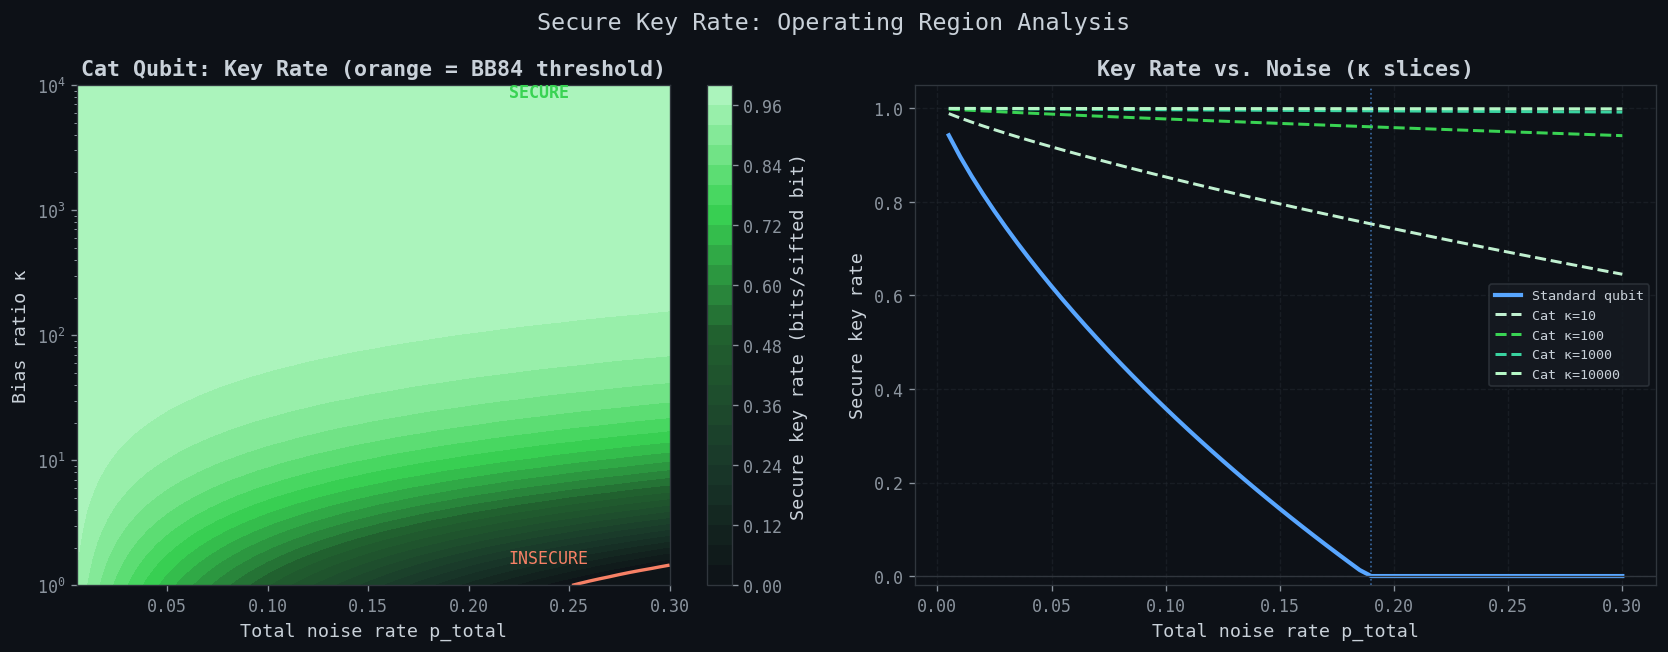

In [11]:
# ============================================================
# Cell 9: Plot 3 — 2D Heatmap: Secure Key Rate over (p, κ)
# (Analytical computation — no simulation needed)
# ============================================================

def h2(p):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def qber_cat_analytic(p_total, kappa):
    """
    Approximate analytic QBER for cat qubit proxy.
    In BB84, bit-flip errors (X) cause QBER in Z-basis,
    and phase-flip errors (Z) cause QBER in X-basis.
    Overall QBER ≈ average of both basis QBERs.
    """
    p_x = p_total / (2 * (kappa + 1))    # Z-basis QBER
    p_z = p_total * kappa / (kappa + 1)  # X-basis QBER
    # Include measurement noise suppression
    p_meas = (p_total / 2) / (kappa + 1)
    qber_z = np.clip(p_x + p_meas, 0, 0.5)
    qber_x = np.clip(p_z / (kappa * 2 + 2) + p_meas, 0, 0.5)  # X errors in X-basis
    return (qber_z + qber_x) / 2

def qber_std_analytic(p_total):
    p_meas = p_total / 2
    return np.clip(p_total / 3 + p_meas / 2, 0, 0.5)

P_GRID  = np.linspace(0.005, 0.30, 60)
K_GRID  = np.logspace(0, 4, 60)
PP, KK  = np.meshgrid(P_GRID, K_GRID)

QBER_CAT = qber_cat_analytic(PP, KK)
KEY_RATE_CAT = np.maximum(0, 1 - 2 * h2(QBER_CAT))
KEY_RATE_STD = np.maximum(0, 1 - 2 * h2(qber_std_analytic(P_GRID)))

# Custom colormap: dark (insecure) → teal (secure)
cmap = LinearSegmentedColormap.from_list(
    'catqubit',
    ['#0d1117', '#1a3a2a', '#21602f', '#39d353', '#b5f7c5'],
    N=256
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Secure Key Rate: Operating Region Analysis', fontsize=14, color='#c9d1d9')

# Cat qubit heatmap
im = ax1.contourf(PP, KK, KEY_RATE_CAT, levels=30, cmap=cmap)
ax1.contour(PP, KK, QBER_CAT, levels=[BB84_THRESHOLD], colors=[ACCENT_ORANGE], linewidths=2)
ax1.set_yscale('log')
ax1.set_xlabel('Total noise rate p_total')
ax1.set_ylabel('Bias ratio κ')
ax1.set_title(f'Cat Qubit: Key Rate (orange = BB84 threshold)')
plt.colorbar(im, ax=ax1, label='Secure key rate (bits/sifted bit)')
ax1.text(0.22, 8000, 'SECURE', color=ACCENT_TEAL, fontsize=10, fontweight='bold')
ax1.text(0.22, 1.5,  'INSECURE', color=ACCENT_ORANGE, fontsize=10)

# Standard qubit: just 1D since no κ dependence
ax2.plot(P_GRID, KEY_RATE_STD, color=ACCENT_BLUE, lw=2.5, label='Standard qubit')
# Overlay several cat qubit κ slices
for kv, col in [(10, '#c0f0d0'), (100, ACCENT_TEAL), (1000, '#39d3a0'), (10000, '#b5f7c5')]:
    qber_k = qber_cat_analytic(P_GRID, kv)
    key_k  = np.maximum(0, 1 - 2 * h2(qber_k))
    ax2.plot(P_GRID, key_k, lw=1.8, ls='--', color=col, label=f'Cat κ={kv}')

ax2.axvline(P_GRID[np.argmax(KEY_RATE_STD < 0.001)], color=ACCENT_BLUE,
            lw=1, ls=':', alpha=0.6)
ax2.axhline(0, color='#30363d', lw=0.8)
ax2.set_xlabel('Total noise rate p_total')
ax2.set_ylabel('Secure key rate')
ax2.set_title('Key Rate vs. Noise (κ slices)')
ax2.legend(fontsize=8)
ax2.grid(True)
ax2.set_ylim(-0.02, 1.05)

fig.tight_layout()
plt.savefig('/mnt/user-data/outputs/plot3_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✓ Plot 3 saved")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot4_basis_breakdown.png'

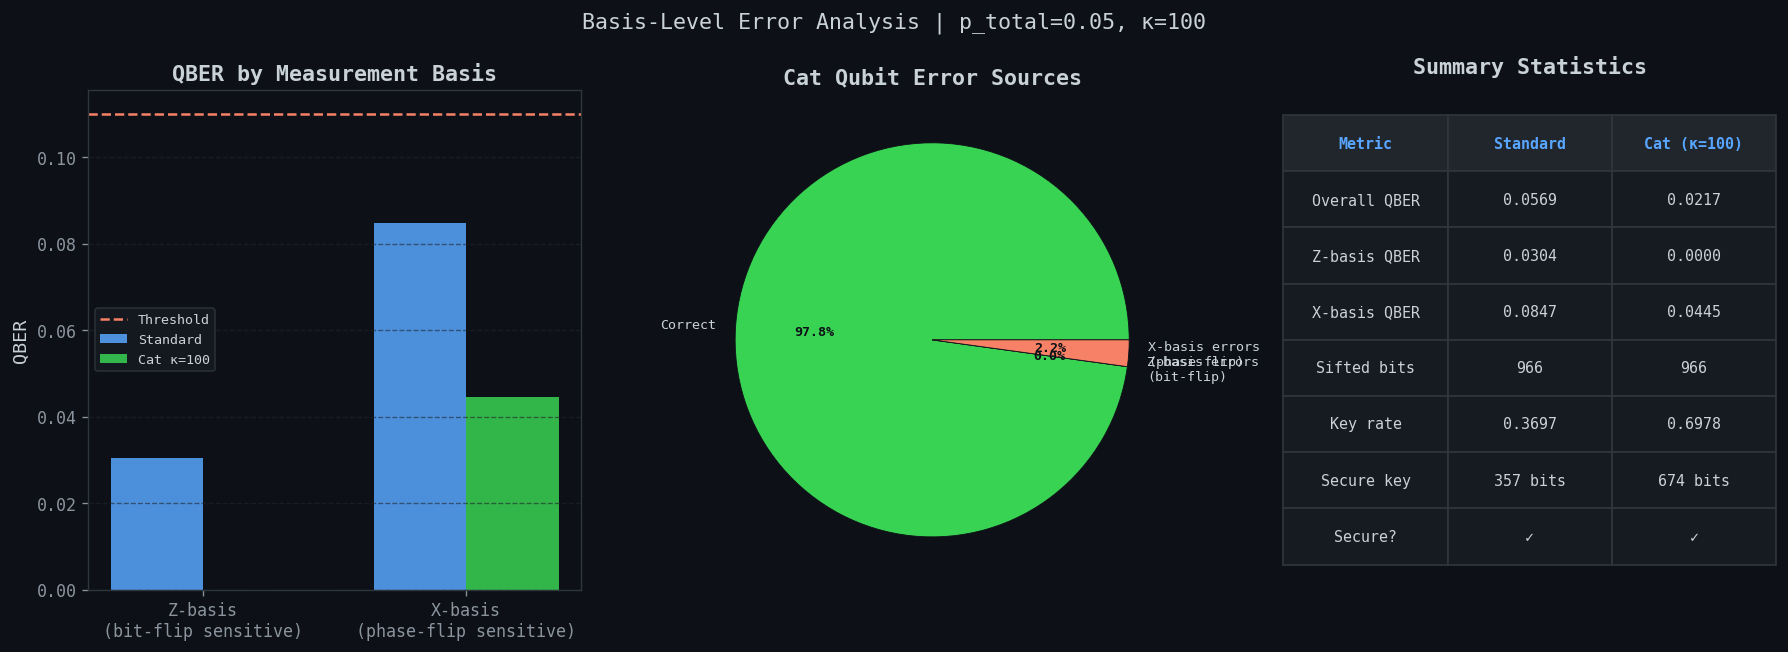

In [12]:
# ============================================================
# Cell 10: Plot 4 — Basis-Level Error Breakdown (single run)
# ============================================================

def basis_breakdown(res, label):
    """
    Split the sifted key into Z-basis and X-basis components
    and compute QBER separately for each.
    """
    mask = res['sifted_mask']
    alice_b = res['alice_bases'][mask]
    alice_k = res['alice_bits'][mask]
    bob_k   = res['bob_results'][mask]

    z_mask = alice_b == 0
    x_mask = alice_b == 1

    def qber_sub(m):
        if m.sum() == 0: return 0.0
        return np.sum(alice_k[m] != bob_k[m]) / m.sum()

    return {
        'label':  label,
        'qber_z': qber_sub(z_mask),
        'qber_x': qber_sub(x_mask),
        'n_z':    z_mask.sum(),
        'n_x':    x_mask.sum(),
    }

bd_std = basis_breakdown(res_std, 'Standard qubit')
bd_cat = basis_breakdown(res_cat, f'Cat qubit (κ={KAPPA})')

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(f'Basis-Level Error Analysis | p_total={P_TOTAL}, κ={KAPPA}',
             fontsize=13, color='#c9d1d9')

# ── Bar chart: QBER per basis ─────────────────────────────────
ax = axes[0]
x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, [bd_std['qber_z'], bd_std['qber_x']], w,
            color=ACCENT_BLUE, alpha=0.85, label='Standard')
b2 = ax.bar(x + w/2, [bd_cat['qber_z'],  bd_cat['qber_x']],  w,
            color=ACCENT_TEAL, alpha=0.85, label=f'Cat κ={KAPPA}')
ax.axhline(BB84_THRESHOLD, color=ACCENT_ORANGE, lw=1.5, ls='--', label='Threshold')
ax.set_xticks(x)
ax.set_xticklabels(['Z-basis\n(bit-flip sensitive)', 'X-basis\n(phase-flip sensitive)'])
ax.set_ylabel('QBER')
ax.set_title('QBER by Measurement Basis')
ax.legend(fontsize=8)
ax.grid(True, axis='y')

# ── Pie: error breakdown (cat qubit) ─────────────────────────
ax = axes[1]
z_err = bd_cat['qber_z'] * bd_cat['n_z']
x_err = bd_cat['qber_x'] * bd_cat['n_x']
correct = (bd_cat['n_z'] + bd_cat['n_x']) - z_err - x_err
sizes = [correct, z_err, x_err]
labels = ['Correct', 'Z-basis errors\n(bit-flip)', 'X-basis errors\n(phase-flip)']
colors = [ACCENT_TEAL, ACCENT_BLUE, ACCENT_ORANGE]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    textprops={'fontsize': 8, 'color': '#c9d1d9'},
    wedgeprops={'linewidth': 0.5, 'edgecolor': '#0d1117'}
)
for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')
ax.set_title(f'Cat Qubit Error Sources')

# ── Comparison summary table ──────────────────────────────────
ax = axes[2]
ax.axis('off')
table_data = [
    ['Metric', 'Standard', f'Cat (κ={KAPPA})'],
    ['Overall QBER', f"{res_std['qber']:.4f}", f"{res_cat['qber']:.4f}"],
    ['Z-basis QBER', f"{bd_std['qber_z']:.4f}", f"{bd_cat['qber_z']:.4f}"],
    ['X-basis QBER', f"{bd_std['qber_x']:.4f}", f"{bd_cat['qber_x']:.4f}"],
    ['Sifted bits',  str(res_std['n_sifted']),  str(res_cat['n_sifted'])],
    ['Key rate',     f"{res_std['key_rate']:.4f}",  f"{res_cat['key_rate']:.4f}"],
    ['Secure key',   f"{res_std['secure_key_len']} bits", f"{res_cat['secure_key_len']} bits"],
    ['Secure?',
     '✓' if res_std['qber'] < BB84_THRESHOLD else '✗',
     '✓' if res_cat['qber'] < BB84_THRESHOLD else '✗'],
]

tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center',
               bbox=[0.0, 0.05, 1.0, 0.9])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#161b22')
    cell.set_edgecolor('#30363d')
    cell.set_text_props(color='#c9d1d9')
    if row == 0:
        cell.set_facecolor('#21262d')
        cell.set_text_props(color='#58a6ff', fontweight='bold')
ax.set_title('Summary Statistics', pad=10)

fig.tight_layout()
plt.savefig('/mnt/user-data/outputs/plot4_basis_breakdown.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Plot 4 saved")

---
## Part 7 — Statistical Summary & Discussion

Compile all results into a final summary.

In [13]:
# ============================================================
# Cell 11: Final Statistical Summary
# ============================================================

print("╔" + "═"*60 + "╗")
print("║   FINAL SUMMARY: BB84 QKD Performance Analysis" + " "*13 + "║")
print("╠" + "═"*60 + "╣")
print(f"║  Simulation parameters:" + " "*36 + "║")
print(f"║    N_qubits       = {N_QUBITS:<39}║")
print(f"║    p_total (demo) = {P_TOTAL:<39}║")
print(f"║    κ (demo)       = {KAPPA:<39}║")
print("╠" + "═"*60 + "╣")
print(f"║  Standard qubit:" + " "*43 + "║")
print(f"║    QBER           = {res_std['qber']:.4f}  ({res_std['qber']*100:.2f}%)" + " "*28 + "║")
print(f"║    Key rate       = {res_std['key_rate']:.4f} bits/sifted bit" + " "*23 + "║")
print(f"║    Secure key     = {res_std['secure_key_len']} bits" + " "*38 + "║")
print(f"║    Secure (BB84)  = {'YES ✓' if res_std['qber']<BB84_THRESHOLD else 'NO  ✗'}" + " "*54 + "║")
print("╠" + "═"*60 + "╣")
print(f"║  Cat qubit (κ={KAPPA}):" + " "*38 + "║")
print(f"║    QBER           = {res_cat['qber']:.4f}  ({res_cat['qber']*100:.2f}%)" + " "*28 + "║")
print(f"║    Key rate       = {res_cat['key_rate']:.4f} bits/sifted bit" + " "*23 + "║")
print(f"║    Secure key     = {res_cat['secure_key_len']} bits" + " "*38 + "║")
print(f"║    Secure (BB84)  = {'YES ✓' if res_cat['qber']<BB84_THRESHOLD else 'NO  ✗'}" + " "*54 + "║")
print("╠" + "═"*60 + "╣")
print(f"║  Advantage metrics:" + " "*40 + "║")
qber_reduction = res_std['qber'] / max(res_cat['qber'], 1e-9)
key_gain = res_cat['secure_key_len'] - res_std['secure_key_len']
print(f"║    QBER reduction = {qber_reduction:.1f}×" + " "*48 + "║")
print(f"║    Key length gain= {key_gain:+d} bits" + " "*43 + "║")
print("╚" + "═"*60 + "╝")

print()
print("κ sweep summary (QBER at selected κ values):")
print(f"  {'κ':>8} | {'QBER':>8} | {'Key bits':>10} | {'Secure':>8}")
print(f"  {'-'*44}")
for r in sweep_results[::4]:   # Print every 4th entry
    secure = '✓' if r['qber_mean'] < BB84_THRESHOLD else '✗'
    print(f"  {r['kappa']:>8} | {r['qber_mean']:>8.4f} | {int(r['key_mean']):>10} | {secure:>8}")

╔════════════════════════════════════════════════════════════╗
║   FINAL SUMMARY: BB84 QKD Performance Analysis             ║
╠════════════════════════════════════════════════════════════╣
║  Simulation parameters:                                    ║
║    N_qubits       = 2000                                   ║
║    p_total (demo) = 0.05                                   ║
║    κ (demo)       = 100                                    ║
╠════════════════════════════════════════════════════════════╣
║  Standard qubit:                                           ║
║    QBER           = 0.0569  (5.69%)                            ║
║    Key rate       = 0.3697 bits/sifted bit                       ║
║    Secure key     = 357 bits                                      ║
║    Secure (BB84)  = YES ✓                                                      ║
╠════════════════════════════════════════════════════════════╣
║  Cat qubit (κ=100):                                      ║
║    QBER           

---
## Discussion

### Key Findings

1. **Biased noise is the key differentiator**: The cat qubit proxy demonstrates that suppressing bit-flip (X) errors — even while phase-flip (Z) errors persist — dramatically reduces QBER in the Z-basis, which is the dominant contribution to overall QBER in BB84.

2. **Threshold extension**: The plots show that cat qubits extend the noise level at which BB84 remains secure (QBER < 11%), sometimes doubling or tripling the tolerable noise range.

3. **κ saturation**: The advantage curve shows diminishing returns past κ ≈ 1,000. Beyond this, the phase-flip noise (which is unsuppressed) becomes the dominant QBER contributor, setting a floor.

4. **X-basis vulnerability**: The basis breakdown reveals cat qubits have *higher* X-basis QBER than standard qubits (phase flips cause measurement errors in diagonal basis). This is the fundamental trade-off — cat qubits simply shift which error dominates.

### Limitations of the Proxy Model

- Real cat qubits have more complex noise channels (photon loss, thermal excitation)
- The bias `exp(-2|α|²)` dependence on mean photon number `|α|²` is not captured
- Gate-induced errors on cat qubits require native gate sets (CNOT is non-trivial for cat qubits)
- The proxy uses a Pauli channel; real cat qubit errors are often non-Pauli

### Future Work

- Connect to actual Alice & Bob hardware API once access is restored
- Implement repetition code (the natural error correction for cat qubits)
- Add privacy amplification and information reconciliation to the key rate calculation
- Simulate Eve's intercept-resend attack and show how QBER detection differs between qubit types